In [16]:
import numpy as np
import matplotlib.pyplot as plt 
plt.rcParams["font.family"] = "Helvetica"
import os
from ADFWI.utils.assessment_metric import *

base_path = "examples/acoustic/04-regularization-techniques-test/01-Marmousi2-Test/data"

no_regularization_path  = os.path.join(base_path,"inversion-no_regularization")
Tikhonov1_path         = os.path.join(base_path,"inversion-Tikhonov1-order")
Tikhonov2_path         = os.path.join(base_path,"inversion-Tikhonov2-order")
TV1_path               = os.path.join(base_path,"inversion-TV1-order")
TV2_path               = os.path.join(base_path,"inversion-TV2-order")

# ad
layers = 88
select_model = -1
no_regularization_v_all   = np.load(os.path.join(no_regularization_path,"iter_vp.npz"))["data"][:,:layers,:]
no_regularization_v       = no_regularization_v_all[select_model]

Tikhonov1_v_all           = np.load(os.path.join(Tikhonov1_path,"iter_vp.npz"))["data"][:,:layers,:]
Tikhonov1_v               = Tikhonov1_v_all[select_model]

Tikhonov2_v_all           = np.load(os.path.join(Tikhonov2_path,"iter_vp.npz"))["data"][:,:layers,:]
Tikhonov2_v               = Tikhonov2_v_all[select_model]

TV1_v_all                 = np.load(os.path.join(TV1_path,"iter_vp.npz"))["data"][:,:layers,:]
TV1_v                     = TV1_v_all[select_model]

TV2_v_all                 = np.load(os.path.join(TV2_path,"iter_vp.npz"))["data"][:,:layers,:]
TV2_v                     = TV2_v_all[select_model]


# misfit 
no_regularization_data_loss= np.load(os.path.join(no_regularization_path,"iter_loss.npz"))["data"]
Tikhonov1_data_loss       = np.load(os.path.join(Tikhonov1_path,"iter_loss.npz"))["data"]
Tikhonov2_data_loss       = np.load(os.path.join(Tikhonov2_path,"iter_loss.npz"))["data"]
TV1_data_loss             = np.load(os.path.join(TV1_path,"iter_loss.npz"))["data"]
TV2_data_loss             = np.load(os.path.join(TV2_path,"iter_loss.npz"))["data"]


In [17]:
init_model = np.load(os.path.join(base_path,"model/init_model.npz"))
true_model = np.load(os.path.join(base_path,"model/true_model.npz"))
init_v = init_model["vp"][:layers,:]
true_v = true_model["vp"][:layers,:]
nz,nx = true_v.shape

### Model Settings

In [18]:
ox,oz = 0,0
nz,nx = 88,200
dx,dz = 40, 40
nt,dt = 1600, 0.003
nabc  = 30
f0    = 5
free_surface = True
x = np.arange(nx)*dx/1000
z = np.arange(nz)*dz/1000
x_mesh,z_mesh = np.meshgrid(x,z)
src_z = np.array([1  for  i in range(2,nx-1,5)])*dz/1000
src_x = np.array([i  for i in range(2,nx-1,5)])*dx/1000
rcv_z = np.array([1  for i in range(1,nx,2)])*dz/1000
rcv_x = np.array([j  for j in range(1,nx,2)])*dz/1000
vmin = true_v.min();vmax = true_v.max()

In [24]:
init_model_loss             =           SSIM(true_v,init_v,win_size=3)
no_regularization_model_loss= np.insert(SSIM(true_v,no_regularization_v_all,win_size=3),0,init_model_loss)
Tikhonov1_model_loss        = np.insert(SSIM(true_v,Tikhonov1_v_all,win_size=3),0,init_model_loss)
Tikhonov2_model_loss        = np.insert(SSIM(true_v,Tikhonov2_v_all,win_size=3),0,init_model_loss)
TV1_model_loss              = np.insert(SSIM(true_v,TV1_v_all,win_size=3),0,init_model_loss)
TV2_model_loss              = np.insert(SSIM(true_v,TV2_v_all,win_size=3),0,init_model_loss)


## Misift and Model

In [25]:
def plot_vel_single_for_all(fig,ax,v,title="",MSE=""):
    plt.rc('font',family='Helvetica')
    # cmap = "bwr"
    cmap = "rainbow"
    # plm = ax.pcolormesh(x_mesh, z_mesh, v,cmap=cmap,vmin=vmin,vmax=vmax)
    x = np.arange(nx*3)*dx/3/1000
    z = np.arange(nz*3)*dz/3/1000
    x_mesh_new,z_mesh_new = np.meshgrid(x,z)
    from scipy.interpolate import griddata
    v_new = griddata((x_mesh.flatten(), z_mesh.flatten()), v.flatten(), (x_mesh_new, z_mesh_new), method='cubic')
    
    plm = ax.pcolormesh(x_mesh_new, z_mesh_new, v_new,cmap=cmap,vmin=vmin,vmax=vmax,shading="nearest")
    ax.invert_yaxis()
    ax.tick_params(labelsize = 16)
    ax.set_title(title,fontsize=16)
    ax.text(5.3,0.35,MSE,fontsize=16,c="w")
    return plm

import matplotlib.transforms as mtransforms
def add_right_cax(ax, pad, width):
    '''
    在一个ax右边追加与之等高的cax.
    pad是cax与ax的间距,width是cax的宽度.
    '''
    axpos = ax.get_position()
    caxpos = mtransforms.Bbox.from_extents(
        axpos.x1 + pad,
        axpos.y0,
        axpos.x1 + pad + width,
        axpos.y1
    )
    cax = ax.figure.add_axes(caxpos)

    return cax

def plot_vel_singleline_for_all(ax,v_true,v_init,v_inv,x_distance,title,show_xlabel=True,show_ylabel=False,show_legend=False):
    ax.plot(v_true[:,int(x_distance//dx)]/1000,  z, c='k',   linewidth=2, linestyle="-" ,label="True")
    ax.plot(v_init[:,int(x_distance//dx)]/1000,  z, c='gray',linewidth=2, linestyle="-" ,label="Init")
    ax.plot(v_inv [:,int(x_distance//dx)]/1000,  z, c='r',   linewidth=2, linestyle="--",label="Inverted")
    ax.tick_params(labelsize = 16)
    if not show_xlabel:
        ax.set_xticks([])
    # else:
    #     ax.tick_params(labelsize = 15)
        
    if not show_ylabel:
        ax.set_yticks([])
    else:
        ax.tick_params(labelsize = 12)
    ax.invert_yaxis()
    
    if show_legend:
        ax.legend(fontsize = 12)
    ax.set_title(title,fontsize=16)

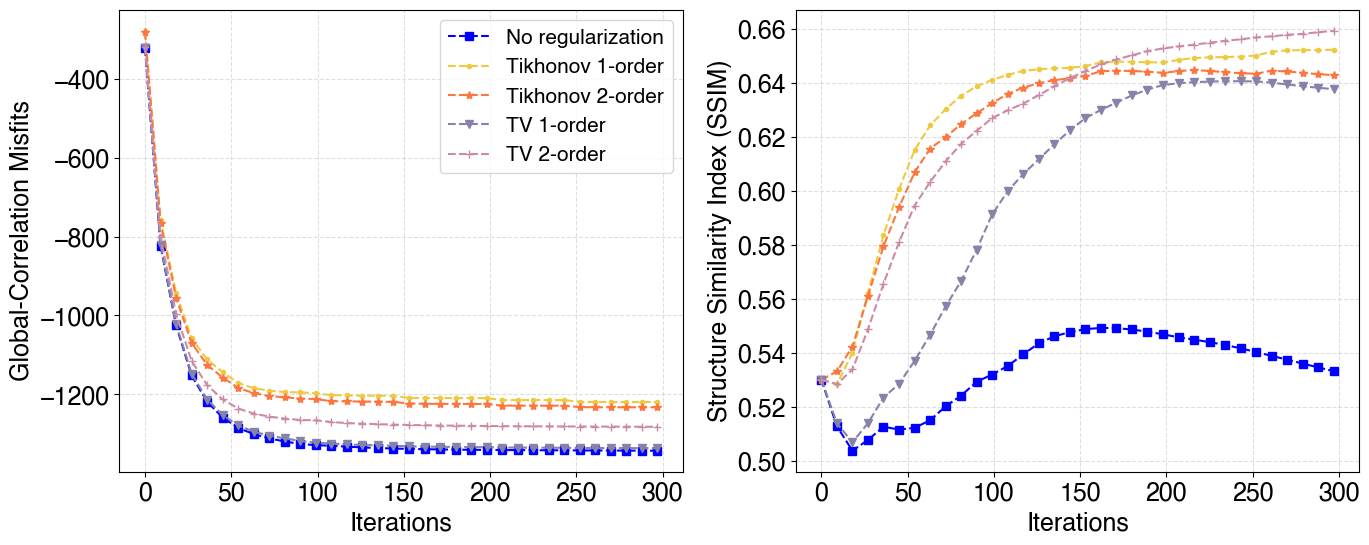

In [26]:
fig,axs = plt.subplots(1,2,figsize=(16,6))
x_lists = np.arange(300)
idx = np.arange(0,len(x_lists)+1,9)

####################################################
# colors: https://zhuanlan.zhihu.com/p/689959306
axs[0].plot(x_lists[idx],no_regularization_data_loss[idx] ,label="No regularization"    ,c='b'           ,linestyle='--' ,marker="s")
axs[0].plot(x_lists[idx],Tikhonov1_data_loss[idx]         ,label=r"Tikhonov 1-order"    ,c='#EECA40'     ,linestyle='--' ,marker=".")
axs[0].plot(x_lists[idx],Tikhonov2_data_loss[idx]         ,label=r"Tikhonov 2-order"    ,c='#FD763F'     ,linestyle='--' ,marker="*")
axs[0].plot(x_lists[idx],TV1_data_loss[idx]               ,label=r"TV 1-order"          ,c='#8583A9'     ,linestyle='--' ,marker="v")
axs[0].plot(x_lists[idx],TV2_data_loss[idx]               ,label=r"TV 2-order"          ,c='#CA8BA8'     ,linestyle='--' ,marker="+")
axs[0].grid(linestyle="--",c="silver",alpha=0.5)
axs[0].set_xlabel("Iterations",fontsize=18)
axs[0].set_ylabel("Global-Correlation Misfits",fontsize=18)
axs[0].tick_params(labelsize=18)
axs[0].legend(fontsize=15)

####################################################
# colors: https://zhuanlan.zhihu.com/p/689959306
axs[1].plot(x_lists[idx],no_regularization_model_loss[idx]  ,label="No regularization"    ,c='b'           ,linestyle='--' ,marker="s")
axs[1].plot(x_lists[idx],Tikhonov1_model_loss[idx]         ,label=r"Tikhonov 1-order"    ,c='#EECA40'     ,linestyle='--' ,marker=".")
axs[1].plot(x_lists[idx],Tikhonov2_model_loss[idx]         ,label=r"Tikhonov 2-order"    ,c='#FD763F'     ,linestyle='--' ,marker="*")
axs[1].plot(x_lists[idx],TV1_model_loss[idx]               ,label=r"TV 1-order"          ,c='#8583A9'     ,linestyle='--' ,marker="v")
axs[1].plot(x_lists[idx],TV2_model_loss[idx]               ,label=r"TV 2-order"          ,c='#CA8BA8'     ,linestyle='--' ,marker="+")
axs[1].grid(linestyle="--",c="silver",alpha=0.5)
axs[1].set_xlabel("Iterations",fontsize=18)
axs[1].set_ylabel("Structure Similarity Index (SSIM)",fontsize=18)
axs[1].tick_params(labelsize=18)

plt.savefig(os.path.join(base_path,"Regularization_Data_and_Model_misfit.png"),bbox_inches='tight',dpi=300)
plt.show()

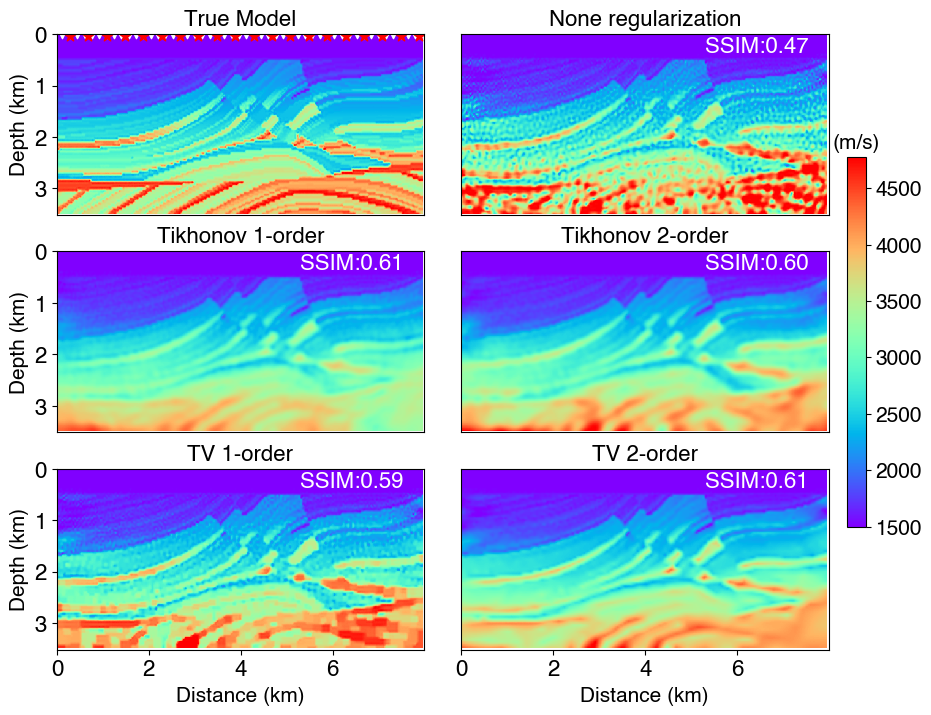

In [28]:
fig,axs = plt.subplots(3,2,figsize=(12,8))
im = plot_vel_single_for_all(fig,axs[0][0],true_v    ,title="True Model")
axs[0][0].scatter(rcv_x[1::2],rcv_z[1::2],c="w",marker="v",s=10)
axs[0][0].scatter(src_x[1::2],src_z[1::2],c="r",marker="*",s=60)
axs[0][0].set_ylabel("Depth (km)",fontsize=15)
axs[0][0].set_ylabel("Depth (km)",fontsize=15)
plot_vel_single_for_all(fig,axs[0][1],no_regularization_v   ,title="None regularization"  ,MSE="SSIM:{:.2f}".format(SSIM(true_v[10::],no_regularization_v[10::],win_size=3)))

plot_vel_single_for_all(fig,axs[1][0],Tikhonov1_v          ,title=r"Tikhonov 1-order"    ,MSE="SSIM:{:.2f}".format(SSIM(true_v[10::],Tikhonov1_v[10::],win_size=3)))
axs[1][0].set_ylabel("Depth (km)",fontsize=15)
plot_vel_single_for_all(fig,axs[1][1],Tikhonov2_v          ,title=r"Tikhonov 2-order"    ,MSE="SSIM:{:.2f}".format(SSIM(true_v[10::],Tikhonov2_v[10::],win_size=3)))

plot_vel_single_for_all(fig,axs[2][0],TV1_v                ,title=r"TV 1-order"          ,MSE="SSIM:{:.2f}".format(SSIM(true_v[10::],TV1_v[10::],win_size=3)))
axs[2][0].set_ylabel("Depth (km)",fontsize=15)
plot_vel_single_for_all(fig,axs[2][1],TV2_v                ,title=r"TV 2-order"          ,MSE="SSIM:{:.2f}".format(SSIM(true_v[10::],TV2_v[10::],win_size=3)))


axs[0][0].set_xticks([])
axs[0][1].set_xticks([])
axs[1][0].set_xticks([])
axs[1][1].set_xticks([])
axs[0][1].set_yticks([])
axs[1][1].set_yticks([])
axs[2][1].set_yticks([])

axs[2][0].set_xlabel("Distance (km)", fontsize=15)
axs[2][1].set_xlabel("Distance (km)", fontsize=15)

plt.subplots_adjust(hspace=0.2,wspace=0.1)

cbar = fig.colorbar(im, ax=axs,orientation='vertical',pad = 0.02,shrink=0.6)
cbar.ax.set_title("(m/s)",fontsize=15,loc='center')
cbar.ax.tick_params(labelsize=15)

plt.savefig(os.path.join(base_path,"Regularization_Model.png"),bbox_inches='tight',dpi=300)
plt.show()